In [3]:
# 引入python库
import mne
from mne.datasets import sample
import matplotlib.pyplot as plt

# sample的存放地址
data_path = sample.data_path(path='D:\Data\EEG')
# 该fif文件存放地址
fname = str(data_path) + '/MEG/sample/sample_audvis_raw.fif'

"""
如果上述给定的地址中存在该文件，则直接加载本地文件，
如果不存在则在网上下载该数据
"""
raw = mne.io.read_raw_fif(fname)

Opening raw data file D:\Data\EEG\MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.


In [6]:
raw.info

Measurement date,"December 03, 2002 19:01:10 GMT"
Experimenter,MEG
Participant,Unknown
Digitized points,146 points
Good channels,"203 Gradiometers, 102 Magnetometers, 9 Stimulus, 59 EEG, 1 EOG"
Bad channels,"MEG 2443, EEG 053"
EOG channels,EOG 061
ECG channels,Not available
Sampling frequency,600.61 Hz
Highpass,0.10 Hz
Lowpass,172.18 Hz


Text(0.5, 1.0, 'Sample channels')

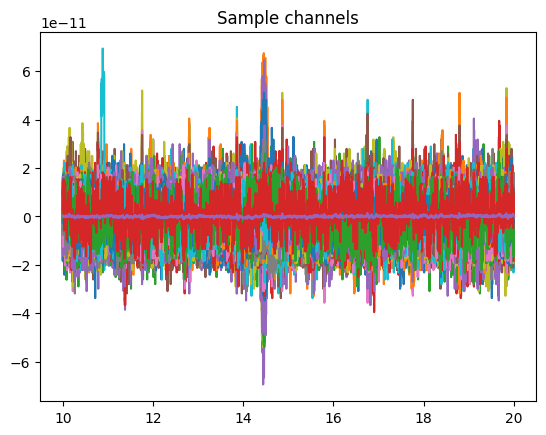

In [7]:
"""
案例：
获取10-20秒内的良好的MEG数据

# 根据type来选择 那些良好的MEG信号(良好的MEG信号，通过设置exclude="bads") channel,
结果为 channels所对应的的索引
"""

picks = mne.pick_types(raw.info, meg=True, exclude='bads')
t_idx = raw.time_as_index([10., 20.])
data, times = raw[picks, t_idx[0]:t_idx[1]]
plt.plot(times,data.T)
plt.title("Sample channels")

Text(0.5, 1.0, 'Sample channels')

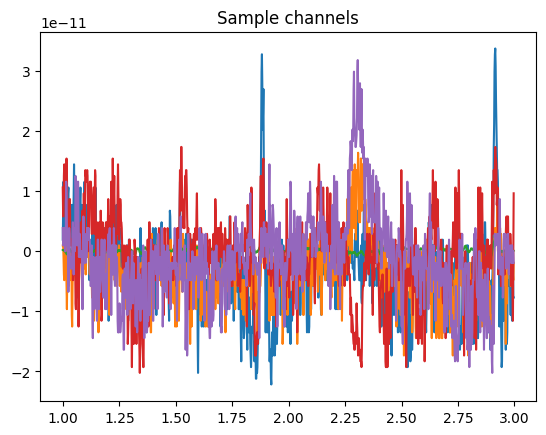

In [8]:
"""
sfreq：采样频率

raw返回所选信道以及时间段内的数据和时间点，
分别赋值给data以及times（即raw对象返回的是两个array）
"""
sfreq=raw.info['sfreq']
data,times=raw[:5,int(sfreq*1):int(sfreq*3)]
plt.plot(times,data.T)
plt.title("Sample channels")

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 3.410 (s)


b:\Anacaonda3\envs\tsarzizi\lib\site-packages\mne\viz\utils.py:165: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  (fig or plt).show(**kwargs)


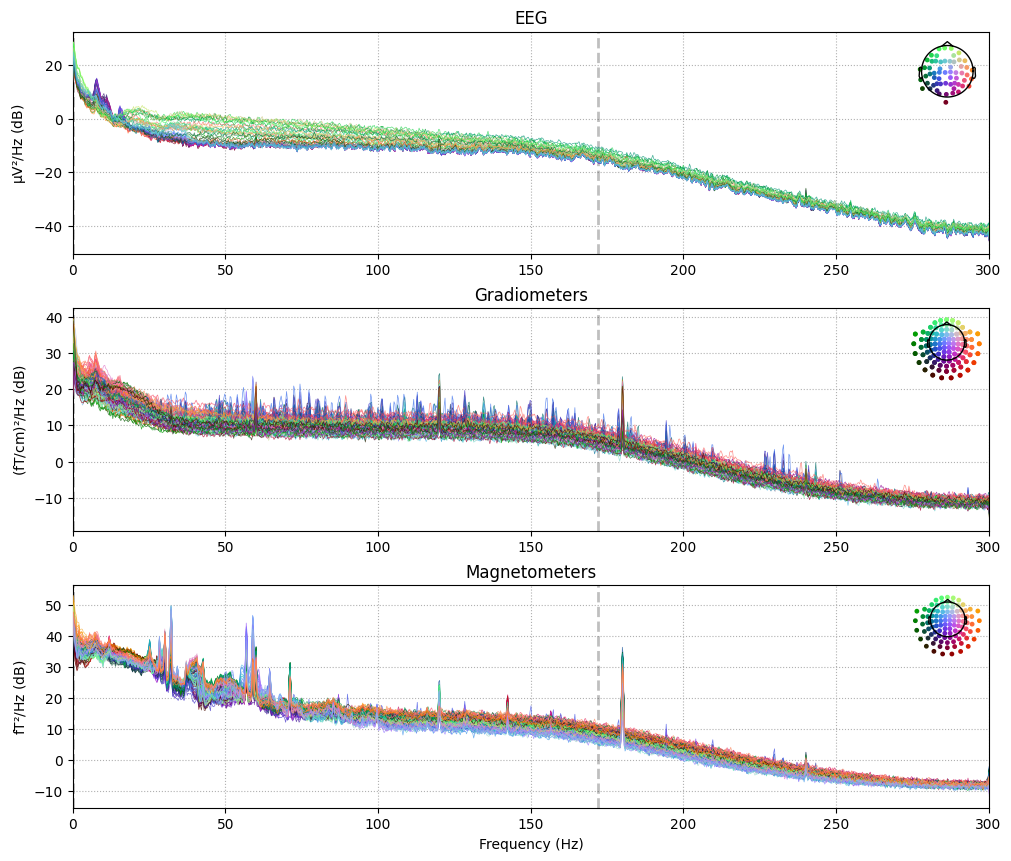

In [9]:
"""
绘制各通道的功率谱密度
"""
raw.plot_psd()
plt.show()

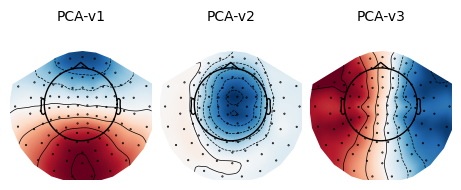

In [10]:
"""
绘制SSP矢量图
"""
raw.plot_projs_topomap()
plt.show()

NOTE: plot_psd_topo() is a legacy function. New code should use .compute_psd().plot_topo().
Effective window size : 3.410 (s)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.8s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.8s finished


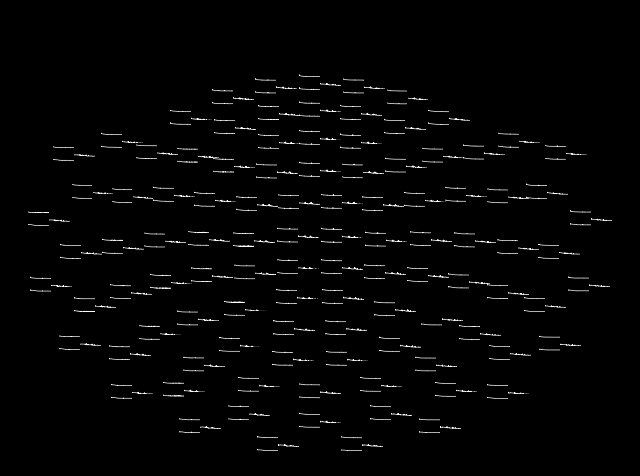

In [11]:
"""
绘制通道频谱图作为topography
"""
raw.plot_psd_topo()
plt.show()

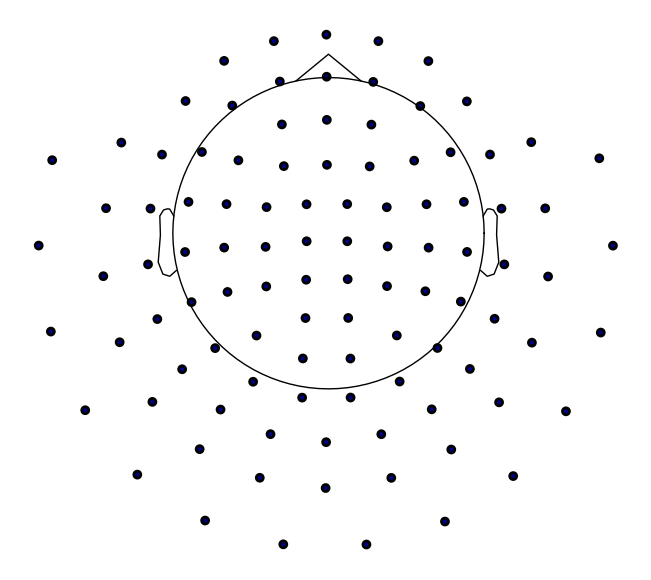

In [12]:
"""
绘制电极位置
"""
raw.plot_sensors()
plt.show()

In [13]:
import mne
import numpy as np
import matplotlib.pyplot as plt

In [14]:
"""
生成一个大小为5x1000的二维随机数据
其中5代表5个通道，1000代表times
"""
data = np.random.randn(5, 1000)

"""
创建info结构,
内容包括：通道名称和通道类型
设置采样频率为:sfreq=100
"""
info = mne.create_info(
    ch_names=['MEG1', 'MEG2', 'EEG1', 'EEG2', 'EOG'],
    ch_types=['grad', 'grad', 'eeg', 'eeg', 'eog'],
    sfreq=100
)
"""
利用mne.io.RawArray类创建Raw对象
"""
custom_raw = mne.io.RawArray(data, info)
print(custom_raw)

Creating RawArray with float64 data, n_channels=5, n_times=1000
    Range : 0 ... 999 =      0.000 ...     9.990 secs
Ready.
<RawArray | 5 x 1000 (10.0 s), ~49 kB, data loaded>


Using matplotlib as 2D backend.


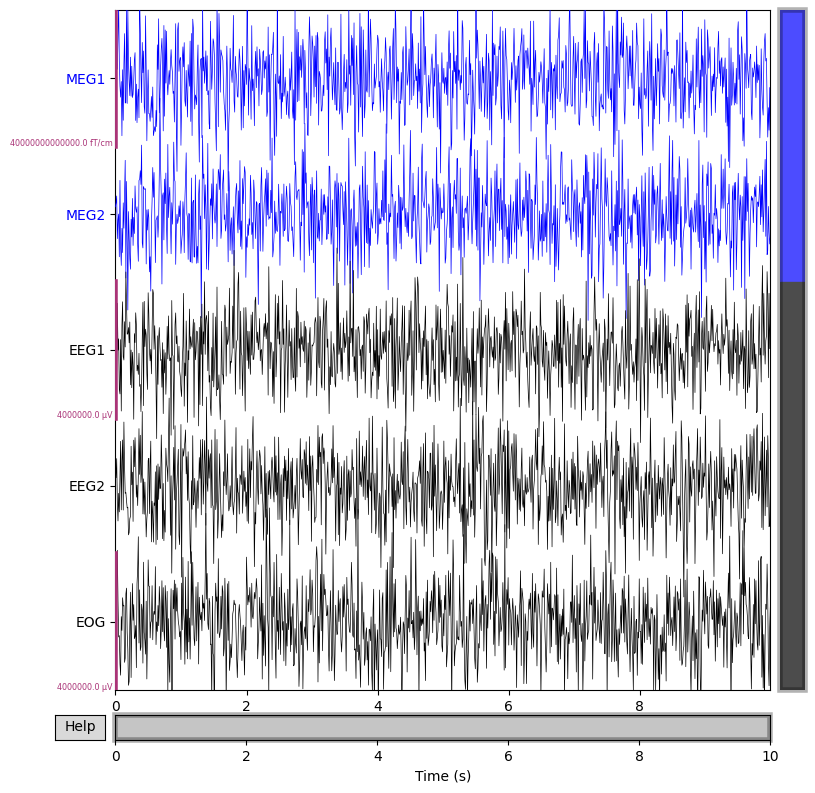

In [15]:
"""
对图形进行缩放

对于实际的EEG / MEG数据，应使用不同的比例因子。
对通道eeg、grad，eog的数据进行2倍缩小
"""
scalings = {'eeg': 2, 'grad': 2,'eog':2}
custom_raw.plot(n_channels=5, 
                scalings=scalings,
                title='Data from arrays',
         show=True, block=True)

plt.show()

In [17]:
import numpy as np
# import neo

import mne
import matplotlib.pyplot as plt

In [18]:
# 创建任意数据
sfreq = 1000  # 采样频率
times = np.arange(0, 10, 0.001)  # Use 10000 samples (10s)

sin = np.sin(times * 10)  # 乘以 10 缩短周期
cos = np.cos(times * 10)
sinX2 = sin * 2
cosX2 = cos * 2

# 数组大小为 4 X 10000.
data = np.array([sin, cos, sinX2, cosX2])

# 定义 channel types and names.
ch_types = ['mag', 'mag', 'grad', 'grad']
ch_names = ['sin', 'cos', 'sinX2', 'cosX2']

In [19]:
"""
创建info对象
"""
info = mne.create_info(ch_names=ch_names,
                       sfreq=sfreq, 
                       ch_types=ch_types)

Creating RawArray with float64 data, n_channels=4, n_times=10000
    Range : 0 ... 9999 =      0.000 ...     9.999 secs
Ready.


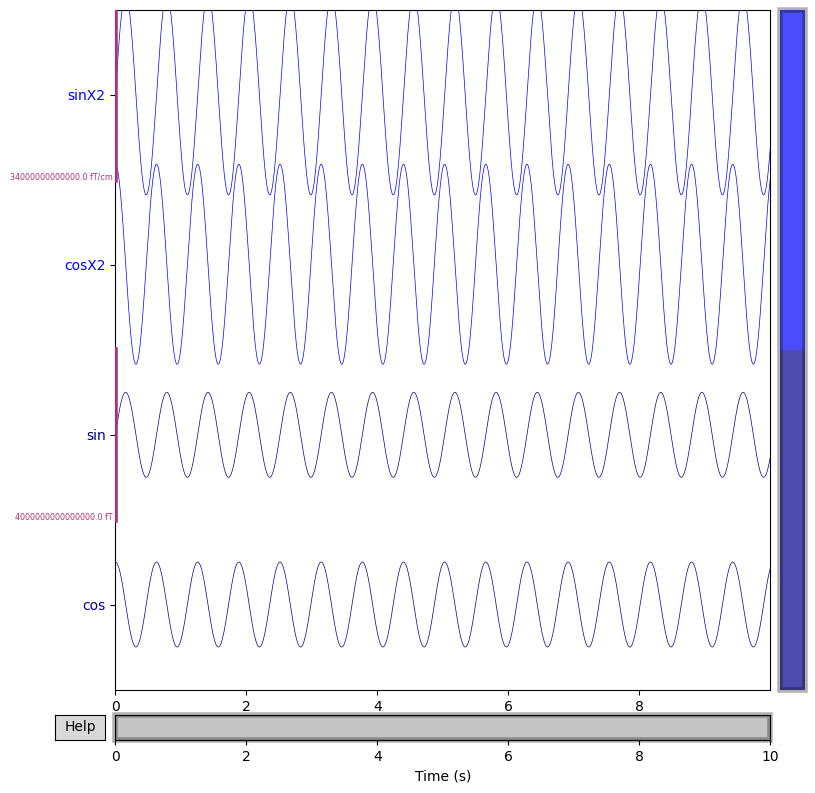

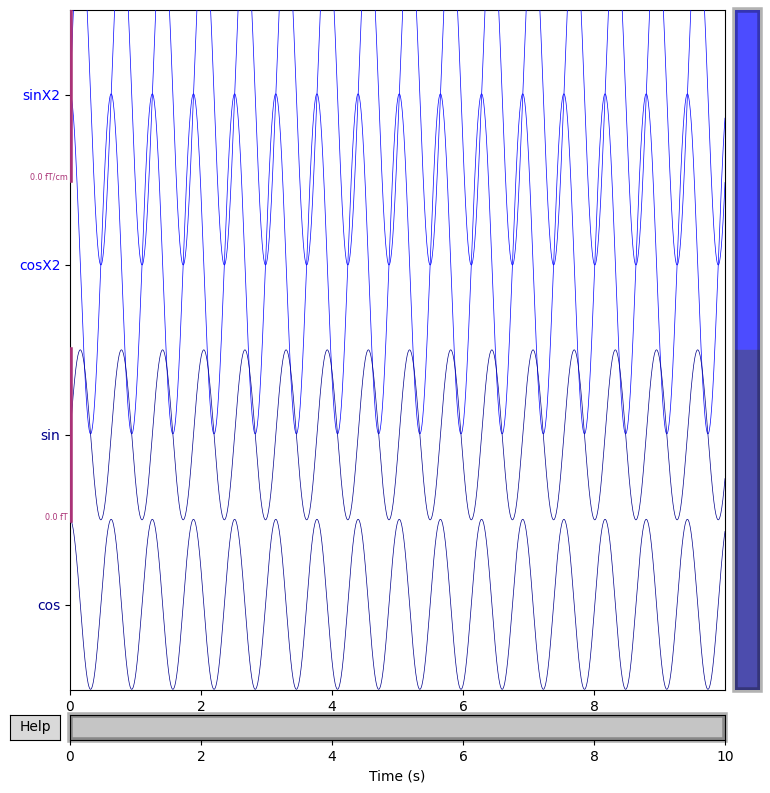

In [20]:
"""
利用mne.io.RawArray创建raw对象
"""
raw = mne.io.RawArray(data, info)

"""
对图形进行缩放

对于实际的EEG / MEG数据，应使用不同的比例因子。

对通道mag的数据进行2倍缩小，对grad的数据进行1.7倍缩小
"""
scalings = {'mag': 2, 'grad':1.7}

raw.plot(n_channels=4, scalings=scalings, title='Data from arrays',
         show=True, block=True)

"""
可以采用自动缩放比例

只要设置scalings='auto'即可
"""
scalings = 'auto'
raw.plot(n_channels=4, scalings=scalings,
         title='Auto-scaled Data from arrays',
         show=True, block=True)
plt.show()

In [3]:

import numpy as np
import matplotlib.pyplot as plt

import mne
from mne.datasets.sleep_physionet.age import fetch_data
from mne.time_frequency import psd_array_welch

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer

Extracting EDF parameters from D:\Data\EEG\physionet-sleep-data\SC4001E0-PSG.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...


Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


C:\Users\Tsarz\AppData\Local\Temp\ipykernel_46432\3403690602.py:28: RuntimeWarning: The unit for channel(s) EMG submental, Event marker, Resp oro-nasal, Temp rectal has changed from V to NA.
  raw_train.set_channel_types(mapping)


Using matplotlib as 2D backend.


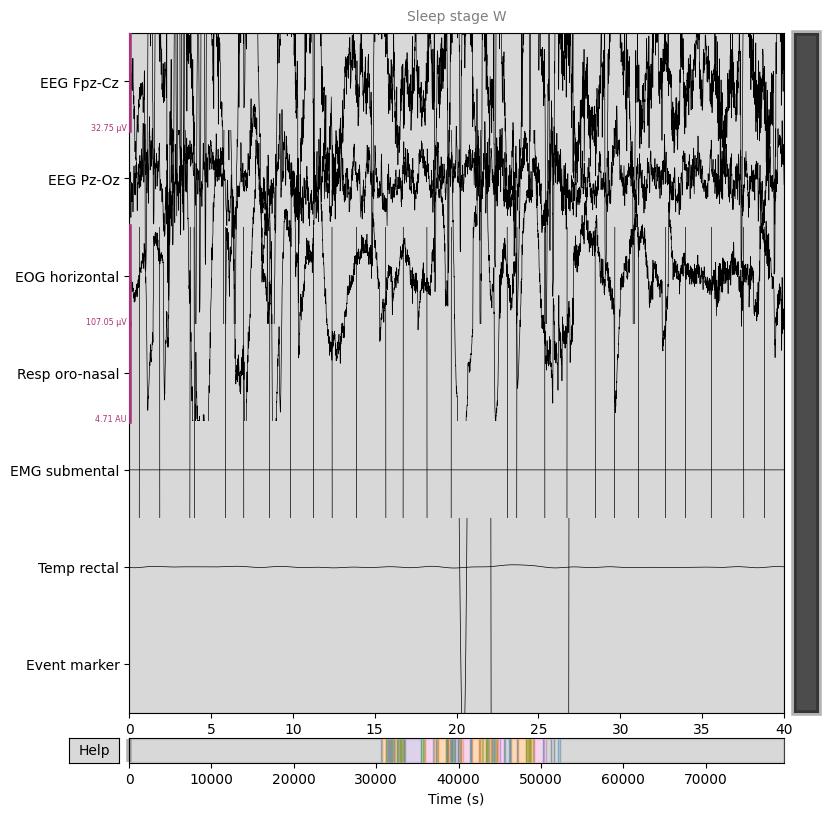

In [4]:

"""
可以通过
mne.datasets.sleep_physionet.age.fetch_data(subjects,recording,path)
来获取PhysioNet多导睡眠图数据集文件。
subjects：表示想要使用哪些受试者对象，可供选择的受试者对象范围为0-19。
recording：表示夜间记录的编号(索引)，有效值为：[1]、[2]或[1、2]。

path:PhysioNet数据的存放地址，如果没有给定，则加载默认存放数据的地址；
如果默认存放数据集的地址不存在数据，则从网络中下载相关数据。
"""
# 选择两个受试者实验对象ALICE, BOB(该名字并非实验中的真实名，这里是为了方便才临时取的名字)
ALICE, BOB = 0, 1
# 加载ALICE, BOB的实验数据文件
[alice_files, bob_files] = fetch_data(subjects=[ALICE, BOB], recording=[1], path="D:\Data\EEG")

# 通道名称映射
mapping = {'EOG horizontal': 'eog',
           'Resp oro-nasal': 'misc',
           'EMG submental': 'misc',
           'Temp rectal': 'misc',
           'Event marker': 'misc'}

#读取ALICE的edf文件，和其对应的注释文件
raw_train = mne.io.read_raw_edf(alice_files[0], preload=True)
annot_train = mne.read_annotations(alice_files[1])

raw_train.set_annotations(annot_train, emit_warning=False)
raw_train.set_channel_types(mapping)

# 绘制空0s开始，时间窗口长度为40s的连续通道数据波形图
raw_train.plot(duration=40, scalings='auto')
plt.show()

Used Annotations descriptions: ['Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage R', 'Sleep stage W']


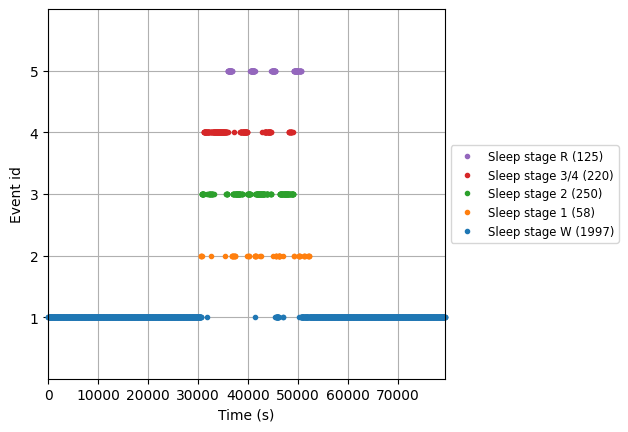

In [5]:
"""
睡眠表示与事件映射
"""
annotation_desc_2_event_id = {'Sleep stage W': 1,
                              'Sleep stage 1': 2,
                              'Sleep stage 2': 3,
                              'Sleep stage 3': 4,
                              'Sleep stage 4': 4,
                              'Sleep stage R': 5}

events_train, _ = mne.events_from_annotations(
    raw_train, event_id=annotation_desc_2_event_id, chunk_duration=30.)

# 创建一个新的event_id以统一 阶段3和4
event_id = {'Sleep stage W': 1,
            'Sleep stage 1': 2,
            'Sleep stage 2': 3,
            'Sleep stage 3/4': 4,
            'Sleep stage R': 5}

# 绘制事件数据
mne.viz.plot_events(events_train, event_id=event_id,
                    sfreq=raw_train.info['sfreq'])

# 保留颜色代码以便进一步绘制
stage_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [6]:
tmax = 30. - 1. / raw_train.info['sfreq']  # tmax in included
"""
所创建的是时间从tmin=0开始，到tmax为止的epochs
"""
epochs_train = mne.Epochs(raw=raw_train, events=events_train,
                          event_id=event_id, tmin=0., tmax=tmax, baseline=None)

print(epochs_train)

Not setting metadata
2650 matching events found
No baseline correction applied
0 projection items activated
<Epochs |  2650 events (good & bad), 0 – 29.99 s, baseline off, ~13 kB, data not loaded,
 'Sleep stage W': 1997
 'Sleep stage 1': 58
 'Sleep stage 2': 250
 'Sleep stage 3/4': 220
 'Sleep stage R': 125>


In [7]:

raw_test = mne.io.read_raw_edf(bob_files[0])
annot_test = mne.read_annotations(bob_files[1])
raw_test.set_annotations(annot_test, emit_warning=False)
raw_test.set_channel_types(mapping)
events_test, _ = mne.events_from_annotations(
    raw_test, event_id=annotation_desc_2_event_id, chunk_duration=30.)
epochs_test = mne.Epochs(raw=raw_test, events=events_test, event_id=event_id,
                         tmin=0., tmax=tmax, baseline=None)

print(epochs_test)

Extracting EDF parameters from D:\Data\EEG\physionet-sleep-data\SC4011E0-PSG.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...


C:\Users\Tsarz\AppData\Local\Temp\ipykernel_46432\1260200900.py:4: RuntimeWarning: The unit for channel(s) EMG submental, Event marker, Resp oro-nasal, Temp rectal has changed from V to NA.
  raw_test.set_channel_types(mapping)


Used Annotations descriptions: ['Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage R', 'Sleep stage W']
Not setting metadata
2802 matching events found
No baseline correction applied
0 projection items activated
<Epochs |  2802 events (good & bad), 0 – 29.99 s, baseline off, ~13 kB, data not loaded,
 'Sleep stage W': 1856
 'Sleep stage 1': 109
 'Sleep stage 2': 562
 'Sleep stage 3/4': 105
 'Sleep stage R': 170>


Using data from preloaded Raw for 58 events and 3000 original time points ...
0 bad epochs dropped


    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs...
Using data from preloaded Raw for 250 events and 3000 original time points ...
0 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs...
Using data from preloaded Raw for 220 events and 3000 original time points ...
0 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs...
Using data from preloaded Raw for 125 events and 3000 original time points ...
0 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs...
Using data from preloaded Raw for 1997 events and 3000 original time points ...
0 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs...
Loading data for 109 events and 3000 original time points ...


C:\Users\Tsarz\AppData\Local\Temp\ipykernel_46432\1740751656.py:10: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].compute_psd().plot(color=color,
C:\Users\Tsarz\AppData\Local\Temp\ipykernel_46432\1740751656.py:10: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].compute_psd().plot(color=color,
C:\Users\Tsarz\AppData\Local\Temp\ipykernel_46432\1740751656.py:10: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].compute_psd().plot(color=color,
C:\Users\Tsarz\A

0 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs...


C:\Users\Tsarz\AppData\Local\Temp\ipykernel_46432\1740751656.py:10: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].compute_psd().plot(color=color,
C:\Users\Tsarz\AppData\Local\Temp\ipykernel_46432\1740751656.py:10: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].compute_psd().plot(color=color,
C:\Users\Tsarz\AppData\Local\Temp\ipykernel_46432\1740751656.py:10: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].compute_psd().plot(color=color,
C:\Users\Tsarz\A

...

C:\Users\Tsarz\AppData\Local\Temp\ipykernel_46432\1740751656.py:10: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].compute_psd().plot(color=color,
C:\Users\Tsarz\AppData\Local\Temp\ipykernel_46432\1740751656.py:10: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].compute_psd().plot(color=color,
C:\Users\Tsarz\AppData\Local\Temp\ipykernel_46432\1740751656.py:10: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].compute_psd().plot(color=color,
C:\Users\Tsarz\A

0 bad epochs dropped


C:\Users\Tsarz\AppData\Local\Temp\ipykernel_46432\1740751656.py:10: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].compute_psd().plot(color=color,
C:\Users\Tsarz\AppData\Local\Temp\ipykernel_46432\1740751656.py:10: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].compute_psd().plot(color=color,
C:\Users\Tsarz\AppData\Local\Temp\ipykernel_46432\1740751656.py:10: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epochs[stage].compute_psd().plot(color=color,
C:\Users\Tsarz\A

    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs...


C:\Users\Tsarz\AppData\Local\Temp\ipykernel_46432\1740751656.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


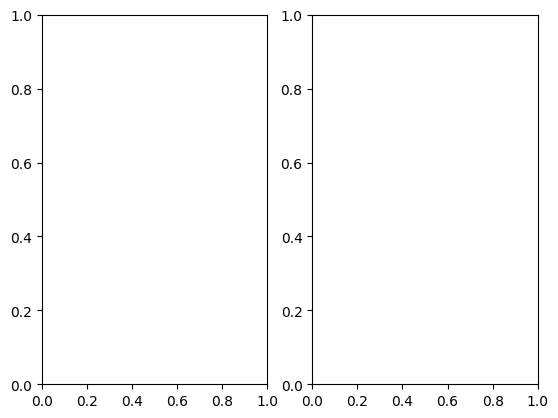

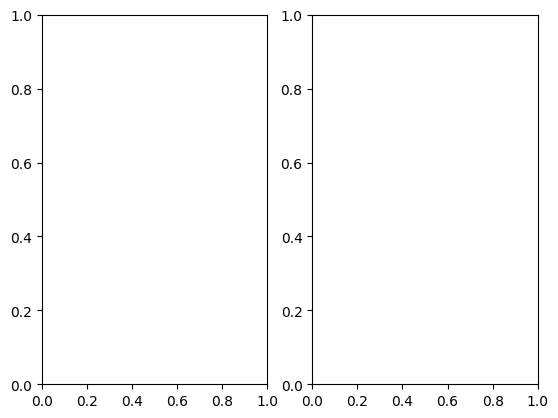

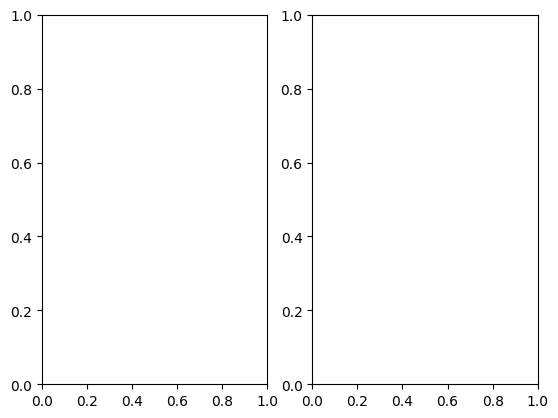

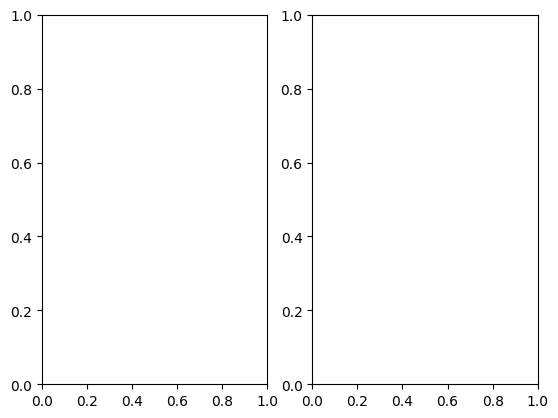

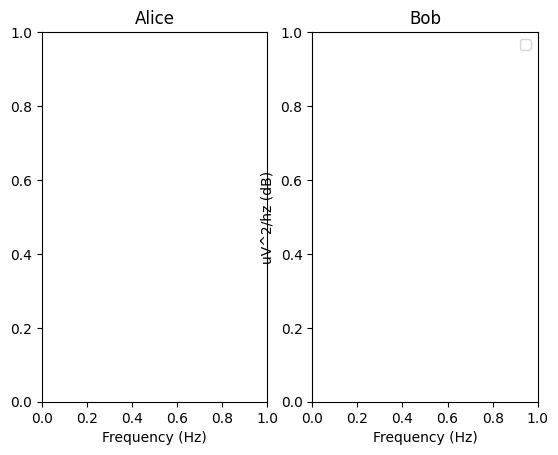

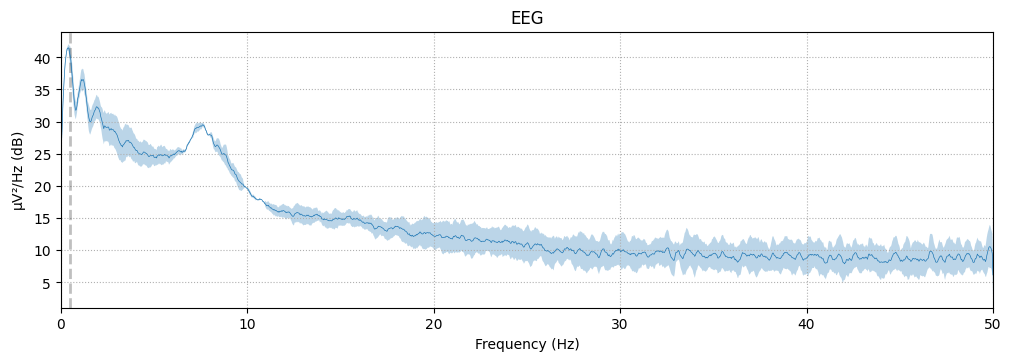

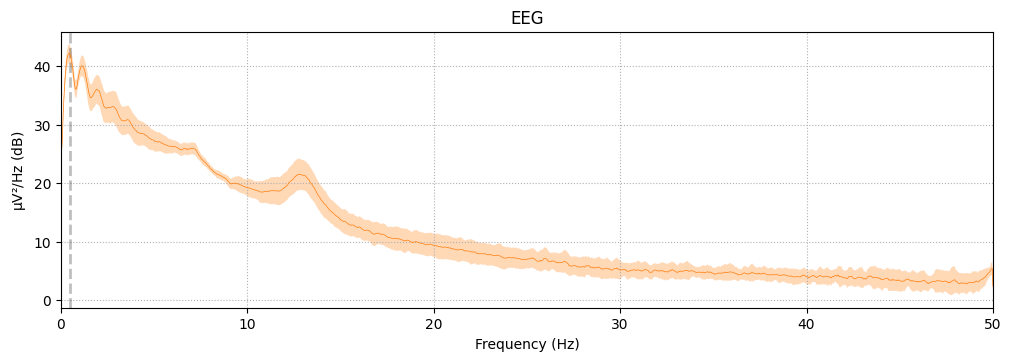

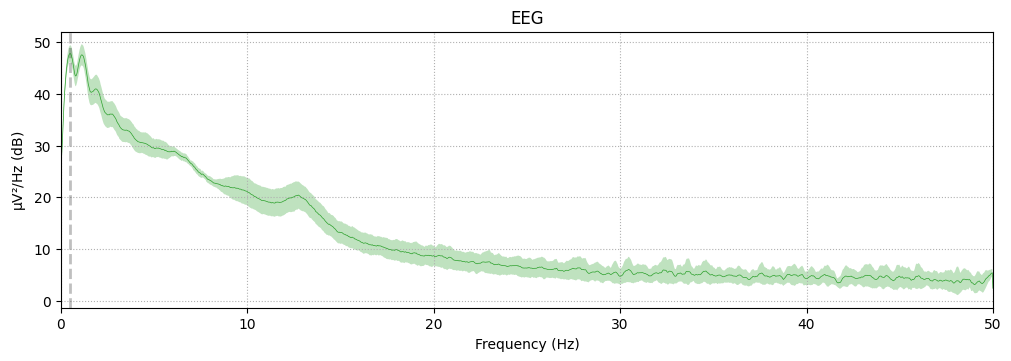

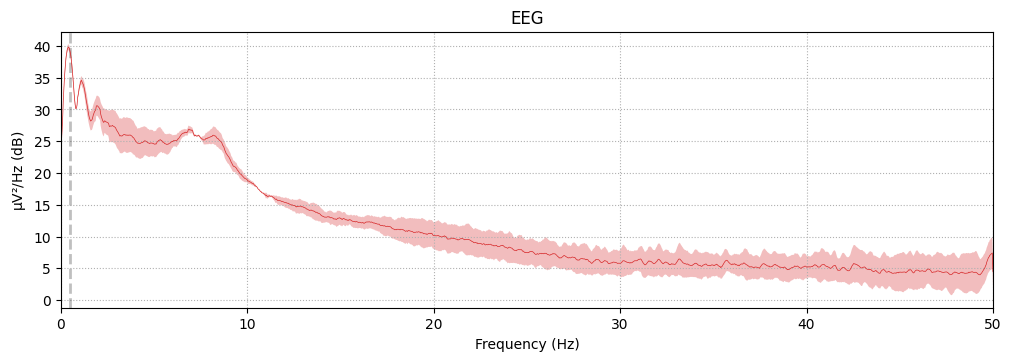

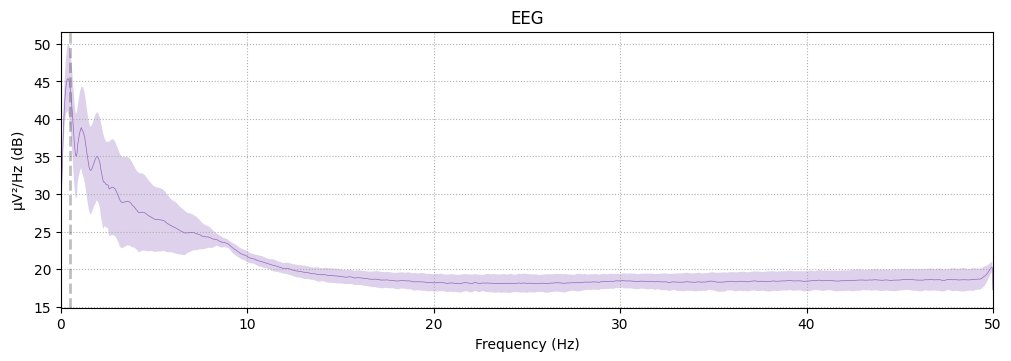

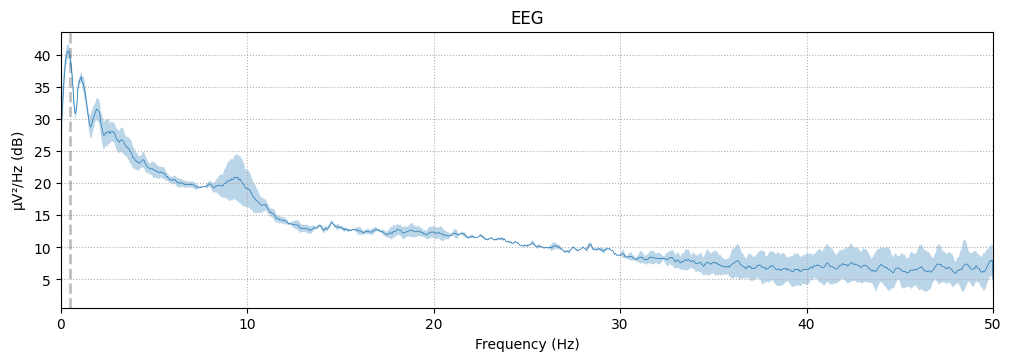

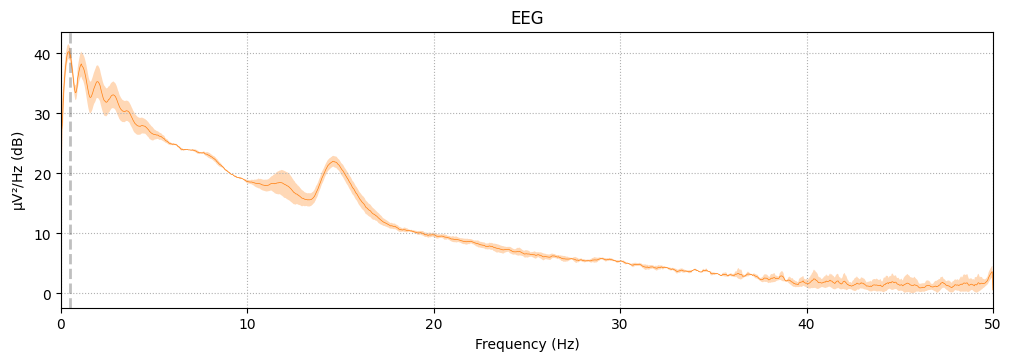

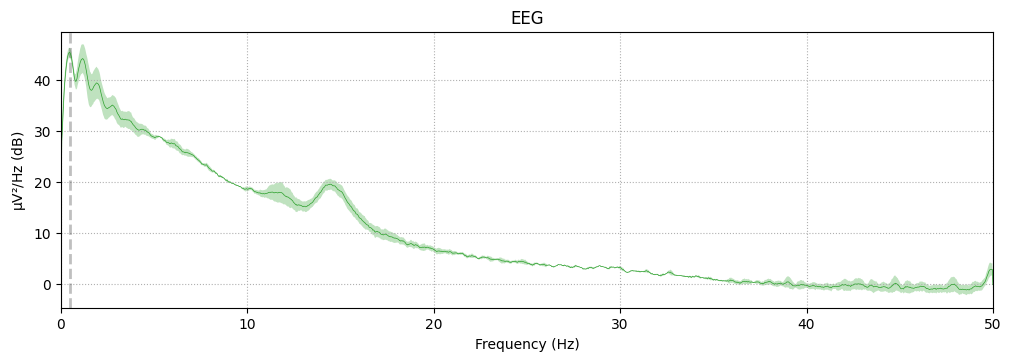

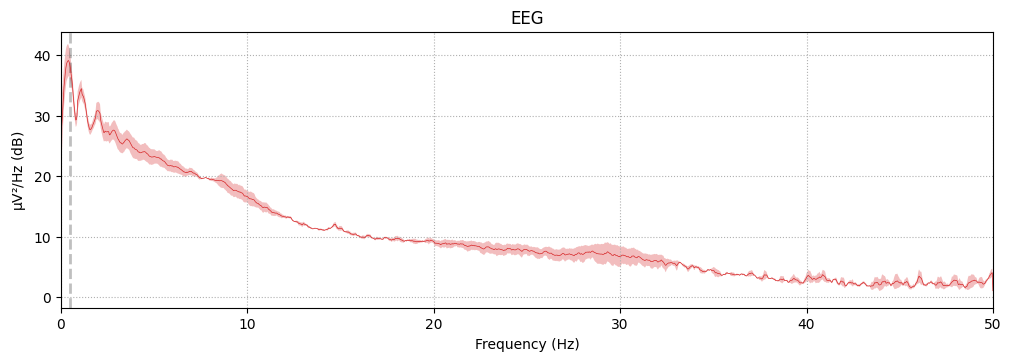

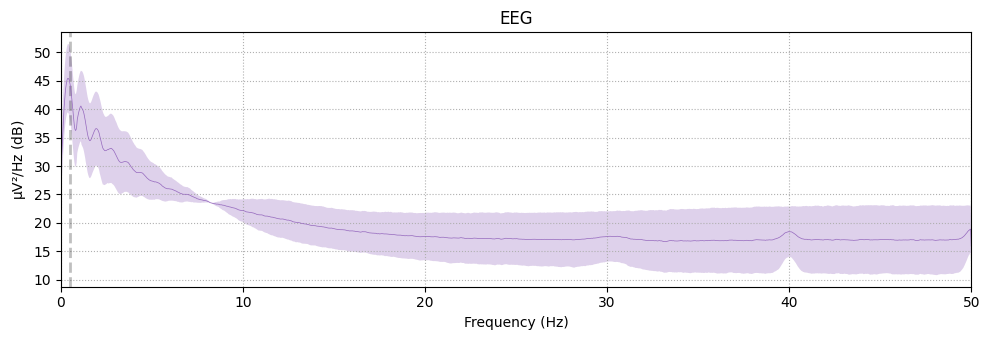

In [15]:

fig, (ax1, ax2) = plt.subplots(ncols=2)

# iterate over the subjects
stages = sorted(event_id.keys())
for ax, title, epochs in zip([ax1, ax2],
                             ['Alice', 'Bob'],
                             [epochs_train, epochs_test]):

    for stage, color in zip(stages, stage_colors):
        epochs[stage].compute_psd().plot(color=color,
                                show=False,
                               average=True, spatial_colors=False)
        #epochs[stage].plot_psd(area_mode=None, color=color, ax=ax,
        #                       fmin=0.1, fmax=20., show=False,
        #                       average=True, spatial_colors=False)
    ax.set(title=title, xlabel='Frequency (Hz)')
ax2.set(ylabel='uV^2/hz (dB)')
ax2.legend(ax2.lines[2::3], stages)
plt.tight_layout()
plt.show()

In [9]:

def eeg_power_band(epochs):
    """脑电相对功率带特征提取
    该函数接受一个""mne.Epochs"对象，
    并基于与scikit-learn兼容的特定频带中的相对功率创建EEG特征。
    Parameters
    ----------
    epochs : Epochs
        The data.
    Returns
    -------
    X : numpy array of shape [n_samples, 5]
        Transformed data.
    """
    # 特定频带
    FREQ_BANDS = {"delta": [0.5, 4.5],
                  "theta": [4.5, 8.5],
                  "alpha": [8.5, 11.5],
                  "sigma": [11.5, 15.5],
                  "beta": [15.5, 30]}

    psds, freqs = psd_welch(epochs, picks='eeg', fmin=0.5, fmax=30.)
    # 归一化 PSDs
    psds /= np.sum(psds, axis=-1, keepdims=True)

    X = []
    for fmin, fmax in FREQ_BANDS.values():
        psds_band = psds[:, :, (freqs >= fmin) & (freqs < fmax)].mean(axis=-1)
        X.append(psds_band.reshape(len(psds), -1))

    return np.concatenate(X, axis=1)

In [10]:

pipe = make_pipeline(FunctionTransformer(eeg_power_band, validate=False),
                     RandomForestClassifier(n_estimators=100, random_state=42))
# 训练
y_train = epochs_train.events[:, 2]
pipe.fit(epochs_train, y_train)

# 预测
y_pred = pipe.predict(epochs_test)

# 评估准确率
y_test = epochs_test.events[:, 2]
acc = accuracy_score(y_test, y_pred)

print("Accuracy score: {}".format(acc))

NameError: name 'psd_welch' is not defined

In [7]:
import numpy as np
test_data = np.random.random(([3, 4, 2]))

test_data

array([[[0.97867846, 0.24306512],
        [0.10797088, 0.02412127],
        [0.10111013, 0.81237475],
        [0.66454762, 0.01897043]],

       [[0.46466609, 0.57305281],
        [0.35180868, 0.25270398],
        [0.31312694, 0.82934312],
        [0.14370811, 0.14617714]],

       [[0.21869415, 0.59075842],
        [0.48669453, 0.19236883],
        [0.7951161 , 0.23652128],
        [0.33965523, 0.84155217]]])

In [8]:
test_data[1, :, :1]

array([[0.46466609],
       [0.35180868],
       [0.31312694],
       [0.14370811]])

[[1 2 0]
 [1 1 3]
 [0 0 2]]


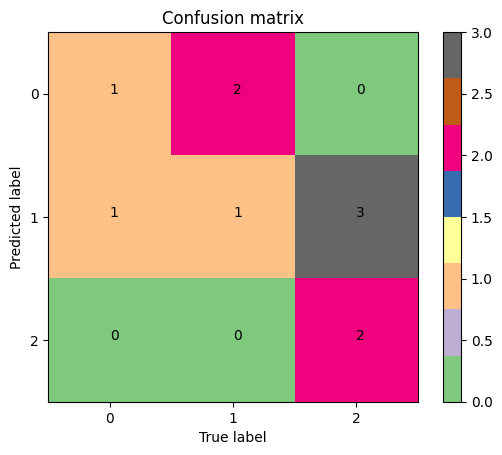

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

True_label = [1,1,1,1,2,0,0,2,0,1]
Pred_label = [2,2,2,1,2,1,1,2,0,0] 
classes = 3

class Drawer:
    def __init__(self, true_label, pred_label, classes):
        self.true_label = true_label
        self.pred_label = pred_label
        self.classes = classes
        self.confusion = confusion_matrix(true_label, pred_label)


    def plot_confusion_matrix(self):
        
        plt.imshow(self.confusion,cmap=plt.cm.Accent)
        classes = range(self.classes)
        indices = range(len(self.confusion))
        plt.xticks(indices, classes)
        plt.yticks(indices, classes)
        plt.colorbar()
        plt.xlabel('True label')
        plt.ylabel('Predicted label')
        plt.title('Confusion matrix')
        
        for first_index in range(len(self.confusion)):
            for second_index in range(len(self.confusion[first_index])):
                plt.text(first_index,second_index,self.confusion[second_index][first_index])
        
        plt.show()
    
    